### Libraries

In [1]:
import os
import sys
import glob
import nibabel as nb
import scipy.stats
from scipy import stats
from brainspace.mesh.mesh_io import read_surface
from brainspace.plotting import plot_hemispheres
from brainspace.gradient import GradientMaps
from brainspace.mesh.array_operations import smooth_array
from brainspace.datasets import load_mask
from brainspace.gradient.utils import dominant_set

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# libraries
import numpy as np
#from brainspace.plotting import plot_hemispheresc
from brainspace.mesh.mesh_io import read_surface
from brainspace.mesh.mesh_creation import build_polydata
import copy
from brainstat.datasets import fetch_mask
import matplotlib.cm as cm
import scipy as sp
import cmocean
from scipy.stats import spearmanr
from scipy.stats import pearsonr

### Functions

In [2]:
def inflate_surf(orig_lh, orig_rh, ref_lh, ref_rh, W=0.15):
    """
    This functions inflates a surface a determined amount [W{0:1}] to a reference
    
    Parameters
    ----------
        orig_lh : vtkPolyData or VTKObjectWrapper
                    left input original surface
        orig_rh : vtkPolyData or VTKObjectWrapper
                    right input original surface
        ref_lh  : vtkPolyData or VTKObjectWrapper
                    left input reference surface
        ref_rh  : vtkPolyData or VTKObjectWrapper
                    right input reference surface
        W       : float value from 0 to 1
        
    Returns
    -------
        new_lh : vtkPolyData or VTKObjectWrapper
                    left output inflated surface
        new_rh : vtkPolyData or VTKObjectWrapper
                    right output inflated surface
        
    """
    def inflate(orig, ref, Winf):
        # Convert BSPolyData objects to numpy arrays
        inf_coord = copy.copy(orig.points)
        inf_triag = copy.copy(orig.GetCells2D())
        
        # Inflated mean surface
        maxs = np.max(orig.points, axis=0)
        mins = np.min(orig.points, axis=0)
        maxsp = np.max(ref.points, axis=0)
        minsp = np.min(ref.points, axis=0)
        
        for i in range(3):
            inf_coord[:,i] = (((ref.points[:, i] - minsp[i]) / (maxsp[i] - minsp[i]))
                                 * (maxs[i] - mins[i]) + mins[i]) * Winf + orig.points[:, i] * (1 - Winf)
        
        # Create the new surface
        new_surf = build_polydata(inf_coord, cells=inf_triag)
        
        return(new_surf)
    
    new_lh = inflate(orig_lh, ref_lh, Winf=W)
    new_rh = inflate(orig_rh, ref_rh, Winf=W)
    
    return(new_lh, new_rh)

# Smooth intencities
def smooth_surf(surf_l, surf_r, points, Mask, Kernel='uniform', Niter=3, Relax=0.35):
    '''
    This function smooth an array (left and right) on a given surface
    Parameters
    ----------
    surf_l : np.array left surface 
    surf_r : np.array right surface
    points : np.array surface data
    Kernel : {'uniform', 'gaussian', 'inverse_distance'}
    Niter  : int, optional Number of smooth iterations
    Relax  : relax : float, optional relaxation factor
    Mask   : str or 1D ndarray, optional
    Returns
    -------
    sdata : smoothed numpy array
    
    '''
    Ndim = Mask.shape[0] 
    n2dim = int(Ndim/2)
    Mask_l=Mask[0:n2dim]
    Mask_r=Mask[n2dim:Ndim]
    sdata = np.concatenate((smooth_array(surf_l, points[0:n2dim],kernel=Kernel, n_iter=Niter,relax=Relax, mask=Mask_l), 
                          smooth_array(surf_r, points[n2dim:Ndim],kernel=Kernel, n_iter=Niter,relax=Relax, mask=Mask_r)), axis=0)
    return(sdata)

# Smooth each intencity
def smooth_intensities(int_profile):
    smoothed_i = np.copy(int_profile)
   
    # smooth each intensity
    for i in range(int_profile.shape[0]):
        smoothed_i[i,:] = smooth_surf(inf_lh, inf_rh, int_profile[i,:], mask_surf, Niter=5, Relax=0.5, Kernel='uniform')
   
    return(smoothed_i)

### Variables

In [3]:
# Set dataset PNI as working directory
os.chdir('/data_/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0')

# Path to MICAPIPE surf = mask_5k !
micapipe=os.popen("echo $MICAPIPE").read()[:-1]

# Load native mid surface
inf_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.inflated.surf.gii', itype='gii')
inf_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.inflated.surf.gii', itype='gii')

inf32_lh = read_surface(micapipe + '/surfaces/fsLR-32k.L.inflated.surf.gii', itype='gii')
inf32_rh = read_surface(micapipe + '/surfaces/fsLR-32k.R.inflated.surf.gii', itype='gii')

mask_lh =  nb.load(micapipe + '/surfaces/fsLR-5k.R.mask.shape.gii').darrays[0].data
mask_rh =  nb.load(micapipe + '/surfaces/fsLR-5k.L.mask.shape.gii').darrays[0].data
mask_5k = np.concatenate((mask_lh, mask_rh), axis=0)

# Load spheres fsLR5k
sphere_lh = read_surface(micapipe+'/surfaces/fsLR-5k.L.sphere.surf.gii', itype='gii')
sphere_rh = read_surface(micapipe+'/surfaces/fsLR-5k.R.sphere.surf.gii', itype='gii')

# load stuff
mask_32k = load_mask(join=True)
mask_surf32 = mask_32k != 0

# Environment variables
surf='fsLR-5k'
out_surf='/host/percy/local_raid/youngeun/LONI/LPBA40.AIR.nifti/JHU-ICBM-SWM/I_figured_out_SWM/rawdata/micapipe_v0.2.0/sub-MNI152/surf'
# Load MNI white matter surface
MNI_wmL = read_surface(f'{out_surf}/sub-MNI152_hemi-L_space-nativepro_surf-{surf}_label-white.surf.gii', itype='gii')
MNI_wmR = read_surface(f'{out_surf}/sub-MNI152_hemi-R_space-nativepro_surf-{surf}_label-white.surf.gii', itype='gii')
# Inflate the INFLATED surface 10% reference to the sphere
ws_lh, ws_rh = inflate_surf(MNI_wmL, MNI_wmR, sphere_lh, sphere_rh, W=0.1)

# Labels and boolean mask
mask_surf = mask_5k != 0

# Inflated fsLR-5k surfaces
inf5_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.inflated.surf.gii', itype='gii')
inf5_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.inflated.surf.gii', itype='gii')

# Load fsaverage5
fs5_lh = read_surface(micapipe+'/surfaces/fsaverage5/surf/lh.pial', itype='fs')
fs5_rh = read_surface(micapipe+'/surfaces/fsaverage5/surf/rh.pial', itype='fs')
fs5_mask = fetch_mask("fsaverage5")

In [4]:
def plot_histogram(data, bins=2000, title='Histogram', cmap='afmhot', Range=(0, 2500),
                   xlim=[0,2500], ylim=2000, mode_value=None, val2=None):
    non_zero_values = data[data != 0]
    n, bins, _ = plt.hist(non_zero_values, bins=bins, color='blue', alpha=0.7)
    bin_centers = (bins[:-1] + bins[1:]) / 2  # Compute the bin centers
    
    colormap = cm.get_cmap(cmap)
    colored_bins = colormap(np.interp(bin_centers, [Range[0], Range[1]], [0, 1]))
    plt.bar(bin_centers, n, width=np.diff(bin_centers[0:2]), color=colored_bins)
    
    plt.title(title)
    #plt.xlabel('Intensity Value')
    #plt.ylabel('Frequency')

    # Remove the outer box line
    for spine in plt.gca().spines.values():
        spine.set_visible(False)
    # Set the grid on the back
    plt.gca().set_axisbelow(True)
    plt.grid(color='gray', linestyle='dashed')

    # Plot a vertical line at the mode value
    if mode_value is not None:
        plt.axvline(x=mode_value[0], color='blue', linestyle='dashed', linewidth=2, label=f'Mode = {mode_value[0]}')
        plt.axvline(x=mode_value[1], color='green', linestyle='dashed', linewidth=2, label=f'Mode = {mode_value[1]}')
    if val2 is not None:
        plt.axvline(x=val2, color='white', linestyle='dashed', linewidth=2, label=f'ModeMRtrix = {val2}')
    
    plt.legend()
    
    # Set x-axis range (adjust as needed)
    plt.xlim(xlim)

    # Set y-axis range (adjust as needed)
    plt.ylim([0, ylim])
    
    plt.show()

In [5]:
map_path = '/data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0/sub-PNC019/ses-a1/maps/'
file_lh_T2orig = map_path + f"sub-PNC019_ses-a1_hemi-L_surf-fsLR-5k_label-midthickness_T2starmap_orig.func.gii"
file_rh_T2orig = map_path + f"sub-PNC019_ses-a1_hemi-R_surf-fsLR-5k_label-midthickness_T2starmap_orig.func.gii"
file_lh_T2proc = map_path + f"sub-PNC019_ses-a1_hemi-L_surf-fsLR-5k_label-midthickness_T2starmap_proc.func.gii"
file_rh_T2proc = map_path + f"sub-PNC019_ses-a1_hemi-R_surf-fsLR-5k_label-midthickness_T2starmap_proc.func.gii"

T2_orig = np.concatenate([nb.load(file_lh_T2orig).darrays[0].data, nb.load(file_rh_T2orig).darrays[0].data])
T2_proc = np.concatenate([nb.load(file_lh_T2proc).darrays[0].data, nb.load(file_rh_T2proc).darrays[0].data])
T2_orig[mask_5k==False] = np.nan
T2_proc[mask_5k==False] = np.nan

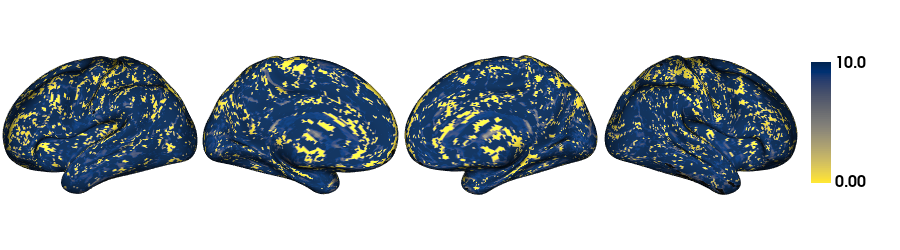

In [36]:
# Path to intensity profile file
intensity_file="/data_/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0/sub-PNC019/ses-a1/mpc/acq-T2starmap_proc/sub-PNC019_ses-a1_surf-fsLR-32k_desc-intensity_profiles.shape.gii"
# 
intensity_map = nb.load(intensity_file).darrays[0].data

intensity_map[intensity_map<0]=0

#crange=(np.quantile(mean5k[mask_5k==True], 0.05), np.quantile(mean5k[mask_5k==True], 0.99))
plot_hemispheres(inf32_lh, inf32_rh, array_name=intensity_map[1,:], size=(900, 250), color_bar='right', zoom=1.25, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='cividis_r', transparent_bg=False, screenshot=False, color_range=(0,10))


/tmp/ipykernel_2537764/828149874.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)
/tmp/ipykernel_2537764/828149874.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


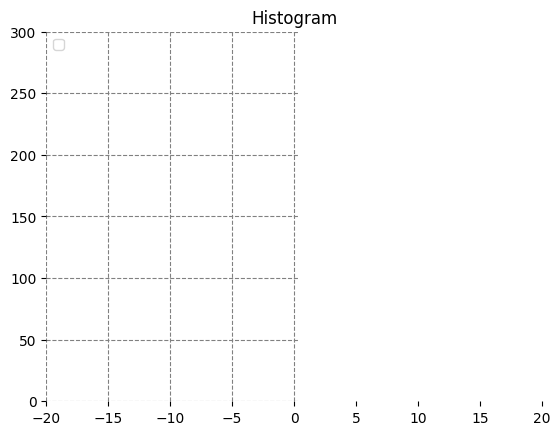

In [34]:
plot_histogram(intensity_map, bins=2000, title='Histogram', cmap='afmhot', Range=(0, 2500),
                   xlim=(-20,20), ylim=300, mode_value=None, val2=None)

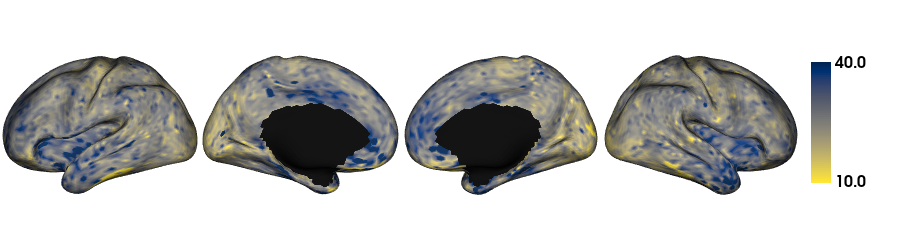

In [6]:
#crange=(np.quantile(mean5k[mask_5k==True], 0.05), np.quantile(mean5k[mask_5k==True], 0.99))
plot_hemispheres(inf_lh, inf_rh, array_name=T2_orig, size=(900, 250), color_bar='right', zoom=1.25, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='cividis_r', transparent_bg=False, screenshot=False, color_range=(10,40))


/tmp/ipykernel_2537764/828149874.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)
/tmp/ipykernel_2537764/828149874.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


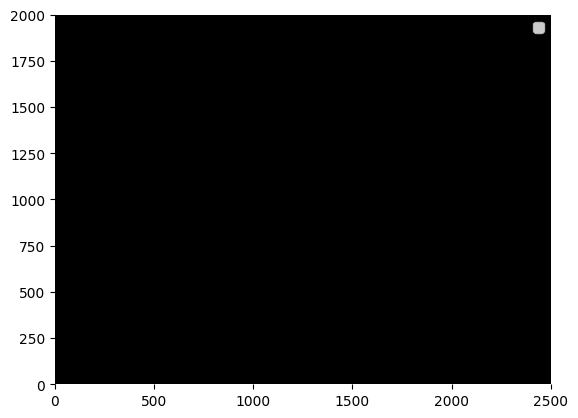

In [15]:
plot_histogram(mean_T1map, bins=1000, title='', cmap='gray', xlim=(1000,2000), ylim=1800, mode_value=None, val2=None)

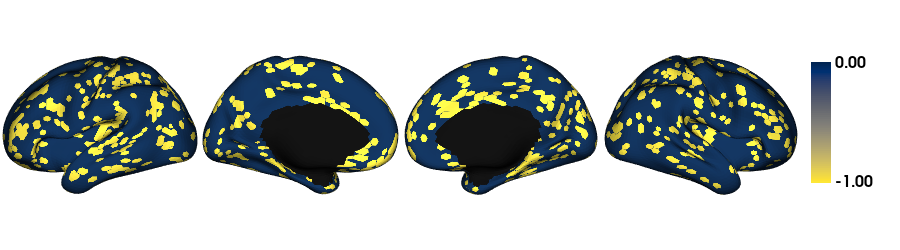

In [10]:
#crange=(np.quantile(mean5k[mask_5k==True], 0.05), np.quantile(mean5k[mask_5k==True], 0.99))
plot_hemispheres(inf_lh, inf_rh, array_name=T2_proc, size=(900, 250), color_bar='right', zoom=1.25, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='cividis_r', transparent_bg=False, screenshot=False, color_range=(-1,0))

/tmp/ipykernel_2537764/828149874.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)
/tmp/ipykernel_2537764/828149874.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


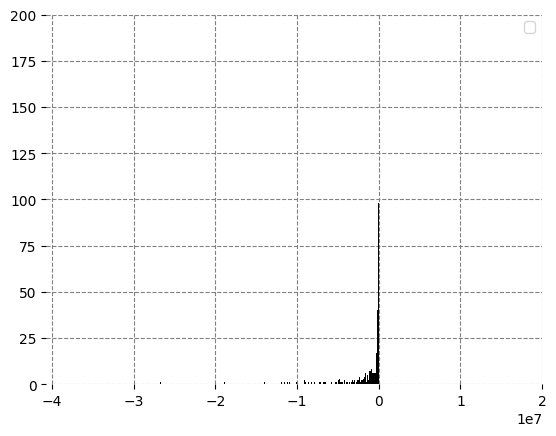

In [9]:
plot_histogram(T2_proc, bins=1000, title='', cmap='gray', xlim=(-40700000,20000000), ylim=200, mode_value=None, val2=None)

## Thresholding 

In [2]:
in_file = "/host/verges/tank/data/youngeun/T2star_preproc/unmasked_T2star/echoes_denoised/FitResults_2025-06-12_08-19-02/T2.nii.gz"
out_file = "/host/verges/tank/data/youngeun/T2star_preproc/unmasked_T2star/echoes_denoised/FitResults_2025-06-12_08-19-02/T2_thr.nii.gz"

nifti_img = nib.load(in_file)
data = nifti_img.get_fdata()

data[data <= 0] = 0 #thresholding

new_img = nib.Nifti1Image(data, affine=nifti_img.affine, header=nifti_img.header)
nib.save(new_img, output_file)

NameError: name 'nib' is not defined